<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/version_pr%C3%A9finale1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/compound"
IMAGE_PATH = os.path.join(BASE_PATH, "Image/aligned")
LABEL_PATH = os.path.join(BASE_PATH, "EmoLabel/list_patition_label.txt")

labels_dict = {}

with open(LABEL_PATH, "r") as f:
    for line in f:
        name, label = line.strip().split()
        labels_dict[name] = int(label) - 1  # 🔥 start from 0

In [5]:
train_images = []
test_images = []

for name in labels_dict.keys():
    if "train" in name:
        train_images.append(name)
    else:
        test_images.append(name)

print(len(train_images), len(test_images))

3162 792


In [6]:
class EmotionDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        real_name = img_name.replace(".jpg", "_aligned.jpg")
        img_path = os.path.join(IMAGE_PATH, real_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # Return black image + correct label to avoid crashing
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        label = labels_dict[img_name]
        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [8]:
train_data, val_data = train_test_split(train_images, test_size=0.2, random_state=42)

train_dataset = EmotionDataset(train_data, transform=train_transform)
val_dataset = EmotionDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True, num_workers=2)

In [9]:
labels_array = [labels_dict[x] for x in train_data]

num_classes = 14
class_weights = np.ones(num_classes)

unique_classes = np.unique(labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=labels_array
)

for i, c in enumerate(unique_classes):
    class_weights[c] = computed_weights[i]

weights = torch.tensor(class_weights, dtype=torch.float)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


In [11]:
model = models.resnet18(weights="DEFAULT")

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, 14)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 51.4MB/s]


In [12]:
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [17]:
# ====================== ENTRAÎNEMENT RESNET - VERSION BOOSTÉE ======================
# Réinitialisation du classifier + unfreezing plus large
model = models.resnet18(weights="DEFAULT")

# Unfreezing plus agressif (layer3 + layer4 + fc)
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),          # Dropout réduit un peu
    nn.Linear(512, 14)
)

model = model.to(device)

# Meilleure gestion des poids
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,                  # LR plus bas + AdamW
    weight_decay=1e-4
)

# Scheduler plus doux
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

num_epochs = 40
best_acc = 0.0
best_model_path = "/content/drive/MyDrive/best_model.pth"

print("🚀 Démarrage entraînement boosté ResNet...")

for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"✅ Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")

    scheduler.step()

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), best_model_path)
        print(f"🔥 Best model saved! New best acc: {best_acc:.2f}%")

print(f"\n🎯 Entraînement terminé. Meilleure accuracy : {best_acc:.2f}%")

🚀 Démarrage entraînement boosté ResNet...

🚀 Epoch 1/40
Batch 0/79 - Loss: 2.7586
Batch 20/79 - Loss: 2.5367
Batch 40/79 - Loss: 2.6043
Batch 60/79 - Loss: 2.6915
✅ Epoch 1 | Loss: 2.5900 | Acc: 17.43%
🔥 Best model saved! New best acc: 17.43%

🚀 Epoch 2/40
Batch 0/79 - Loss: 2.1268
Batch 20/79 - Loss: 2.3823
Batch 40/79 - Loss: 2.3914
Batch 60/79 - Loss: 2.2873
✅ Epoch 2 | Loss: 2.2465 | Acc: 25.99%
🔥 Best model saved! New best acc: 25.99%

🚀 Epoch 3/40
Batch 0/79 - Loss: 2.0479
Batch 20/79 - Loss: 2.1216
Batch 40/79 - Loss: 1.8642
Batch 60/79 - Loss: 1.9914
✅ Epoch 3 | Loss: 2.0525 | Acc: 28.78%
🔥 Best model saved! New best acc: 28.78%

🚀 Epoch 4/40
Batch 0/79 - Loss: 1.6260
Batch 20/79 - Loss: 1.6722
Batch 40/79 - Loss: 1.9777
Batch 60/79 - Loss: 2.0645
✅ Epoch 4 | Loss: 1.9351 | Acc: 29.61%
🔥 Best model saved! New best acc: 29.61%

🚀 Epoch 5/40
Batch 0/79 - Loss: 1.9055
Batch 20/79 - Loss: 1.9658
Batch 40/79 - Loss: 1.5020
Batch 60/79 - Loss: 1.9628
✅ Epoch 5 | Loss: 1.7964 | Acc: 3

In [18]:
# ====================== CELLULE 4 : CLASS NAMES, PROMPTS & DEVICE ======================
class_names = [
    "Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry", "Sadly Surprised",
    "Fearfully Surprised", "Angrily Surprised", "Disgustedly Surprised"
]

text_prompts = [
    "a person smiling with raised eyebrows", "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face", "a smiling person with slight disgust",
    "a sad person with fearful eyes", "an angry person with surprised expression",
    "a sad person with raised eyebrows", "a disgusted person with surprised face",
    "a person with wide eyes and open mouth", "an angry person with disgust expression",
    "a sad person with disgust expression", "a smiling person with anger",
    "a fearful person with anger", "a neutral face"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


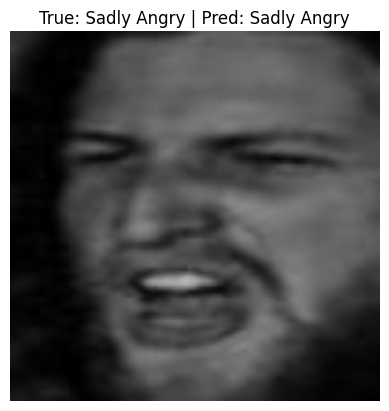

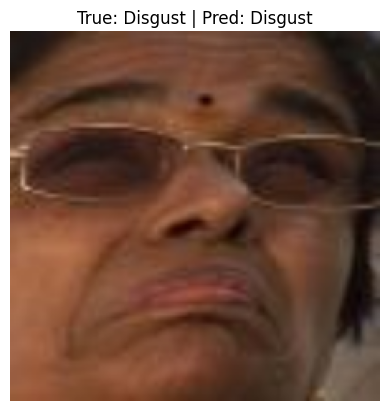

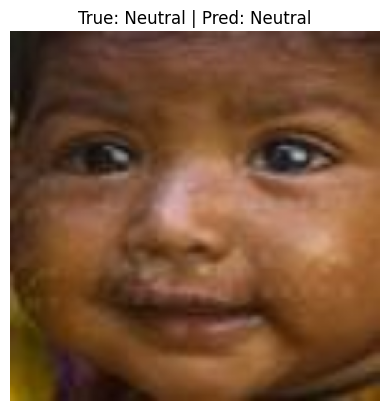

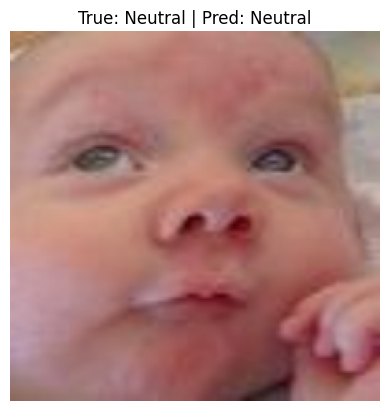

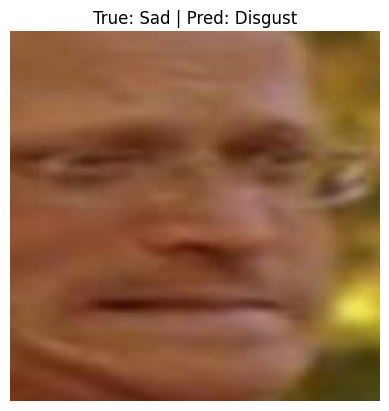

In [19]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

              precision    recall  f1-score   support

           0       0.56      0.57      0.57       100
           1       0.36      0.37      0.36        49
           2       0.18      0.13      0.15        23
           3       0.26      0.29      0.27        21
           4       0.06      0.06      0.06        17
           5       0.56      0.59      0.58       118
           6       0.52      0.58      0.55        19
           7       0.53      0.63      0.58        76
           8       0.31      0.31      0.31        29
           9       0.62      0.54      0.58       127
          10       0.24      0.21      0.22        29

    accuracy                           0.49       608
   macro avg       0.38      0.39      0.38       608
weighted avg       0.49      0.49      0.49       608



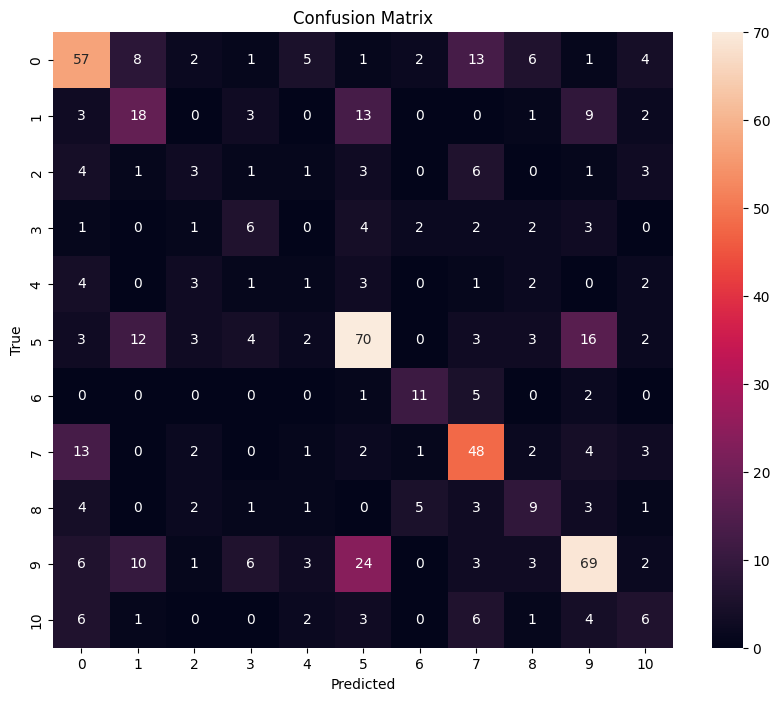

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [21]:
!pip install open_clip_torch streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 125.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print("✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit")

✅ Imports supplémentaires ajoutés pour CLIP + Grad-CAM + Streamlit


In [23]:
import torch
import open_clip
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_clip, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model_clip = model_clip.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [27]:
# ====================== CELLULE 6 : CLIP + QLoRA FINE-TUNING ======================
!pip install bitsandbytes # Install the missing library
!pip install --upgrade torchao # Upgrade torchao for peft compatibility
import open_clip
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from bitsandbytes.optim import AdamW8bit

model_clip, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model_clip = model_clip.to(device)

lora_config = LoraConfig(
    r=32, lora_alpha=64,
    target_modules="all-linear",
    lora_dropout=0.1,
    bias="none",
    task_type="FEATURE_EXTRACTION"
)

model_clip = prepare_model_for_kbit_training(model_clip)
model_clip = get_peft_model(model_clip, lora_config)
model_clip.print_trainable_parameters()

optimizer_clip = AdamW8bit(model_clip.parameters(), lr=5e-5, weight_decay=0.01)

def train_clip_one_epoch_qlora(loader):
    model_clip.train()
    total_loss = 0.0
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        texts = [text_prompts[l.item()] for l in labels]
        text_tokens = open_clip.tokenize(texts).to(device)

        image_features = model_clip.encode_image(images)
        text_features = model_clip.encode_text(text_tokens)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        loss = torch.nn.CrossEntropyLoss()(logits, torch.arange(len(images), device=device))

        optimizer_clip.zero_grad()
        loss.backward()
        optimizer_clip.step()
        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")

    return total_loss / len(loader)

print("🚀 Fine-tuning CLIP avec QLoRA...")
for epoch in range(8):
    loss = train_clip_one_epoch_qlora(train_loader)
    print(f"CLIP Epoch {epoch+1}/8 | Loss: {loss:.4f}")

# Sauvegarde
save_dir = "/content/drive/MyDrive/clip_qlora_ferce_final"
os.makedirs(save_dir, exist_ok=True)
model_clip.save_pretrained(save_dir)
print(f"✅ CLIP QLoRA sauvegardé dans : {save_dir}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 112.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


trainable params: 5,898,240 || all params: 157,175,553 || trainable%: 3.7526
🚀 Fine-tuning CLIP avec QLoRA...
Batch 0/79 - Loss: 3.4662
Batch 10/79 - Loss: 3.4456
Batch 20/79 - Loss: 3.4298
Batch 30/79 - Loss: 3.3399
Batch 40/79 - Loss: 3.2481
Batch 50/79 - Loss: 3.2687
Batch 60/79 - Loss: 3.2103
Batch 70/79 - Loss: 3.1656
CLIP Epoch 1/8 | Loss: 3.3158
Batch 0/79 - Loss: 3.2701
Batch 10/79 - Loss: 3.1287
Batch 20/79 - Loss: 3.1385
Batch 30/79 - Loss: 3.1615
Batch 40/79 - Loss: 3.0379
Batch 50/79 - Loss: 3.0815
Batch 60/79 - Loss: 3.0708
Batch 70/79 - Loss: 3.0941
CLIP Epoch 2/8 | Loss: 3.1101
Batch 0/79 - Loss: 3.1684
Batch 10/79 - Loss: 3.1666
Batch 20/79 - Loss: 3.0332
Batch 30/79 - Loss: 3.0905
Batch 40/79 - Loss: 2.9944
Batch 50/79 - Loss: 2.9782
Batch 60/79 - Loss: 3.1130
Batch 70/79 - Loss: 3.0658
CLIP Epoch 3/8 | Loss: 3.0418
Batch 0/79 - Loss: 2.9840
Batch 10/79 - Loss: 2.9645
Batch 20/79 - Loss: 2.9965
Batch 30/79 - Loss: 3.0426
Batch 40/79 - Loss: 3.0781
Batch 50/79 - Loss: 2

In [28]:
text_tokens = open_clip.tokenize(text_prompts).to(device)

def predict_clip(image):
    image_input = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text_tokens)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)

    pred = probs.argmax().item()
    return pred, probs[0][pred].item()

🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...
✅ CLIP Evaluation terminée !
                   precision    recall  f1-score   support

          Neutral       0.74      0.67      0.71       100
            Happy       0.25      0.33      0.29        49
              Sad       0.18      0.13      0.15        23
         Surprise       0.29      0.19      0.23        21
             Fear       0.12      0.06      0.08        17
          Disgust       0.77      0.43      0.55       118
            Angry       0.45      0.68      0.54        19
         Contempt       0.48      0.67      0.56        76
Happily Surprised       0.26      0.45      0.33        29
      Sadly Angry       0.65      0.71      0.68       127
  Sadly Surprised       0.16      0.14      0.15        29

         accuracy                           0.51       608
        macro avg       0.40      0.41      0.39       608
     weighted avg       0.54      0.51      0.51       608



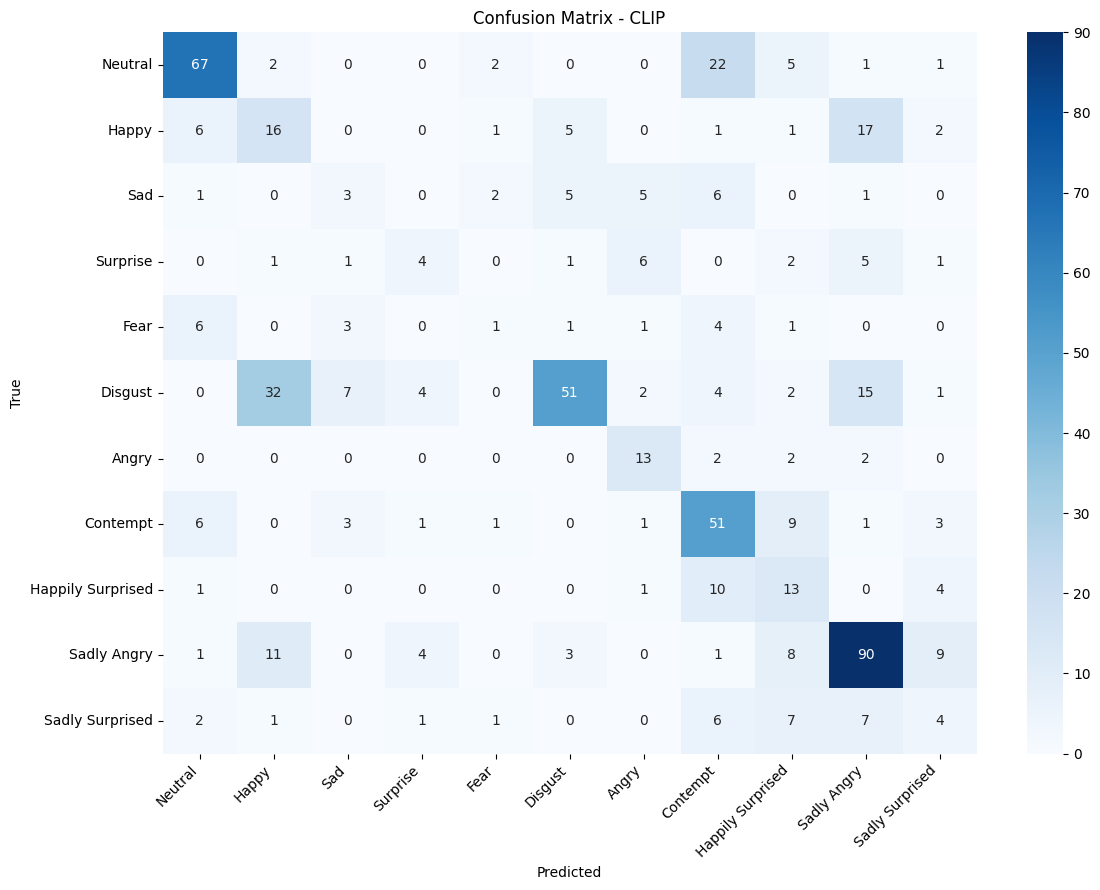

Average CLIP confidence: 0.1466


In [29]:
# ====================== ÉVALUATION CLIP SUR VAL DATASET ======================
print("🚀 Évaluation complète CLIP sur le validation set (RAF-CE)...")

y_true_clip = []
y_pred_clip = []
clip_confidences = []

model_clip.eval()

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):
        for j in range(images.size(0)):  # une image à la fois car predict_clip prend PIL
            img_tensor = images[j]
            # reconvertir en PIL pour predict_clip
            # Denormalize image for PIL conversion
            img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * 0.5 + 0.5) * 255 # Denormalize from [-1, 1] to [0, 255]
            img_pil = Image.fromarray(img_np.astype(np.uint8))

            pred, conf = predict_clip(img_pil)
            y_pred_clip.append(pred)
            y_true_clip.append(labels[j].item())
            clip_confidences.append(conf)

print("✅ CLIP Evaluation terminée !")

# Get unique labels present in the data
unique_labels = sorted(list(np.unique(y_true_clip)))
# Filter class names to match only the unique labels present
filtered_class_names = [class_names[i] for i in unique_labels]

# Report
print(classification_report(y_true_clip, y_pred_clip, labels=unique_labels, target_names=filtered_class_names))

# Confusion matrix CLIP
cm_clip = confusion_matrix(y_true_clip, y_pred_clip, labels=unique_labels)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_clip, annot=True, fmt='d', cmap='Blues',
            xticklabels=filtered_class_names, yticklabels=filtered_class_names)
plt.title("Confusion Matrix - CLIP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Average CLIP confidence: {np.mean(clip_confidences):.4f}")

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [31]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        # On cible la dernière couche de layer4 (la plus efficace pour la localisation)
        self.target_layer = model.layer4[-1] if hasattr(model.layer4, '__getitem__') else model.layer4

        # Hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()

        # Vérification de sécurité
        if self.gradients is None or self.activations is None:
            print("⚠️  Gradients ou activations non capturés")
            # Retourner une heatmap vide en cas d'erreur
            return np.zeros((224, 224), dtype=np.float32)

        gradients = self.gradients[0].cpu().numpy()      # shape: (C, H, W)
        activations = self.activations[0].cpu().numpy()

        # Calcul des poids
        weights = np.mean(gradients, axis=(1, 2))        # (C,)

        # Création de la carte d'activation
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)                         # ReLU
        cam = cv2.resize(cam, (224, 224))

        # Normalisation
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        # Lissage pour réduire le bruit
        cam = cv2.GaussianBlur(cam, (5, 5), 0)

        return cam

In [32]:
def analyze_attention(cam):
    h, w = cam.shape

    # Zones plus précises pour les émotions faciales
    top_third    = np.mean(cam[:int(h*0.35)])           # sourcils + haut des yeux
    eyes_zone    = np.mean(cam[int(h*0.25):int(h*0.45)])
    mouth_zone   = np.mean(cam[int(h*0.62):int(h*0.85)])

    scores = {
        "eyebrows_and_eyes": top_third + eyes_zone * 0.7,
        "mouth": mouth_zone
    }

    best = max(scores, key=scores.get)
    return best.replace("_", " ")

In [33]:
gradcam = GradCAM(model)   # nouvelle version
print("✅ Grad-CAM corrigé et initialisé")

✅ Grad-CAM corrigé et initialisé


🚀 Test CLIP + Grad-CAM sur : /content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg


/tmp/ipykernel_5069/1288452519.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


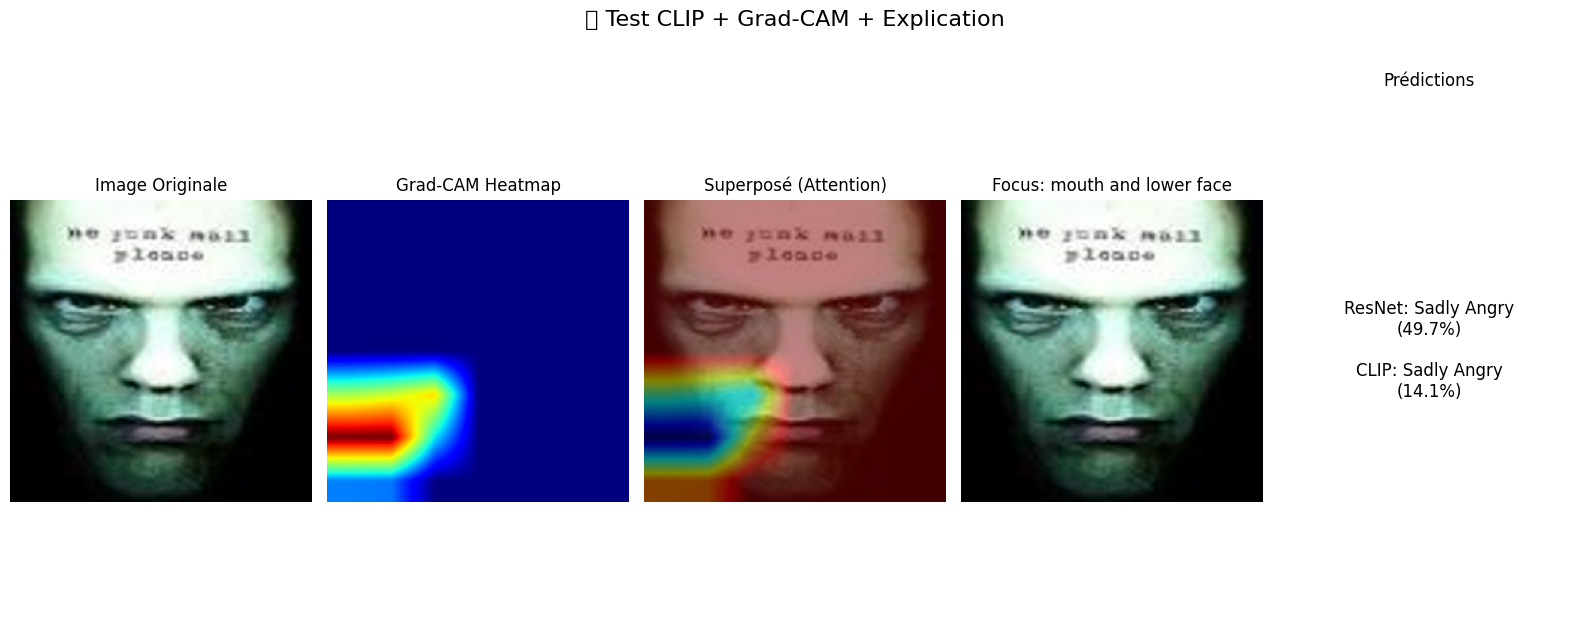

🧠 Explication : 'Sadly Angry' - Focus on mouth and lower face.
📍 Zone d'attention détectée : mouth and lower face
📊 Confiance CLIP : 14.12%


In [34]:
# ====================== TEST CLIP + GRAD-CAM SUR UNE SEULE IMAGE (VERSION CORRIGÉE) ======================
import cv2
import numpy as np

# Define analyze_attention (improved version from app.py) within this cell
def analyze_attention(cam):
    h, w = cam.shape
    # Diviser en 3 zones : sourcils/yeux | nez | bouche
    top = np.mean(cam[:int(h*0.35)])      # sourcils + yeux
    middle = np.mean(cam[int(h*0.35):int(h*0.65)])
    bottom = np.mean(cam[int(h*0.65):])   # bouche

    if top > bottom and top > middle:
        return "eyes and eyebrows"
    elif bottom > top and bottom > middle:
        return "mouth and lower face"
    else:
        return "central face (nose/eyes area)"

# Define generate_explanation within this cell
def generate_explanation(pred_class, cam):
    emotion = class_names[pred_class]
    focus = analyze_attention(cam)
    return f"'{emotion}' - Focus on {focus}."


test_image_path = "/content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg"

print(f"🚀 Test CLIP + Grad-CAM sur : {test_image_path}")

# Chargement de l'image
test_img = Image.open(test_image_path).convert("RGB")

# 1. Prédiction ResNet + Grad-CAM
img_tensor = val_transform(test_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_cnn = torch.argmax(probs, dim=1).item()

cam = gradcam.generate(img_tensor, pred_cnn)

# 2. Prédiction CLIP
pred_clip_idx, conf_clip = predict_clip(test_img)
pred_clip_name = class_names[pred_clip_idx]

# 3. Analyse de la zone d'attention
focus_area = analyze_attention(cam)

# 4. Explication (maintenant corrigée)
explanation = generate_explanation(pred_cnn, cam)

# 5. Affichage
img_np = np.array(test_img.resize((224, 224)))

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255.0
superimposed = heatmap + np.float32(img_np) / 255.0
superimposed = superimposed / np.max(superimposed)

plt.figure(figsize=(16, 6))

plt.subplot(1, 5, 1)
plt.imshow(img_np)
plt.title("Image Originale")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(superimposed)
plt.title("Superposé (Attention)")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(img_np)
plt.title(f"Focus: {focus_area}")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.text(0.5, 0.5, f"ResNet: {class_names[pred_cnn]}\n({probs[0][pred_cnn]*100:.1f}%)\n\n"
                    f"CLIP: {pred_clip_name}\n({conf_clip*100:.1f}%)",
         ha='center', va='center', fontsize=12)
plt.title("Prédictions")
plt.axis("off")

plt.suptitle("✅ Test CLIP + Grad-CAM + Explication", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("🧠 Explication :", explanation)
print(f"📍 Zone d'attention détectée : {focus_area}")
print(f"📊 Confiance CLIP : {conf_clip*100:.2f}%")


🚀 Test sur 6 images aléatoires du Validation Set

Image 1: True = Angry | ResNet = Angry | CLIP = Angry
   → 'Angry' - Focus on mouth and lower face.

Image 2: True = Neutral | ResNet = Neutral | CLIP = Neutral
   → 'Neutral' - Focus on central face (nose/eyes area).

Image 3: True = Sadly Angry | ResNet = Sadly Angry | CLIP = Sadly Angry
   → 'Sadly Angry' - Focus on central face (nose/eyes area).

Image 4: True = Neutral | ResNet = Happily Surprised | CLIP = Neutral
   → 'Happily Surprised' - Focus on mouth and lower face.

Image 5: True = Disgust | ResNet = Neutral | CLIP = Disgust
   → 'Neutral' - Focus on mouth and lower face.

Image 6: True = Sadly Angry | ResNet = Sadly Angry | CLIP = Sadly Angry
   → 'Sadly Angry' - Focus on mouth and lower face.



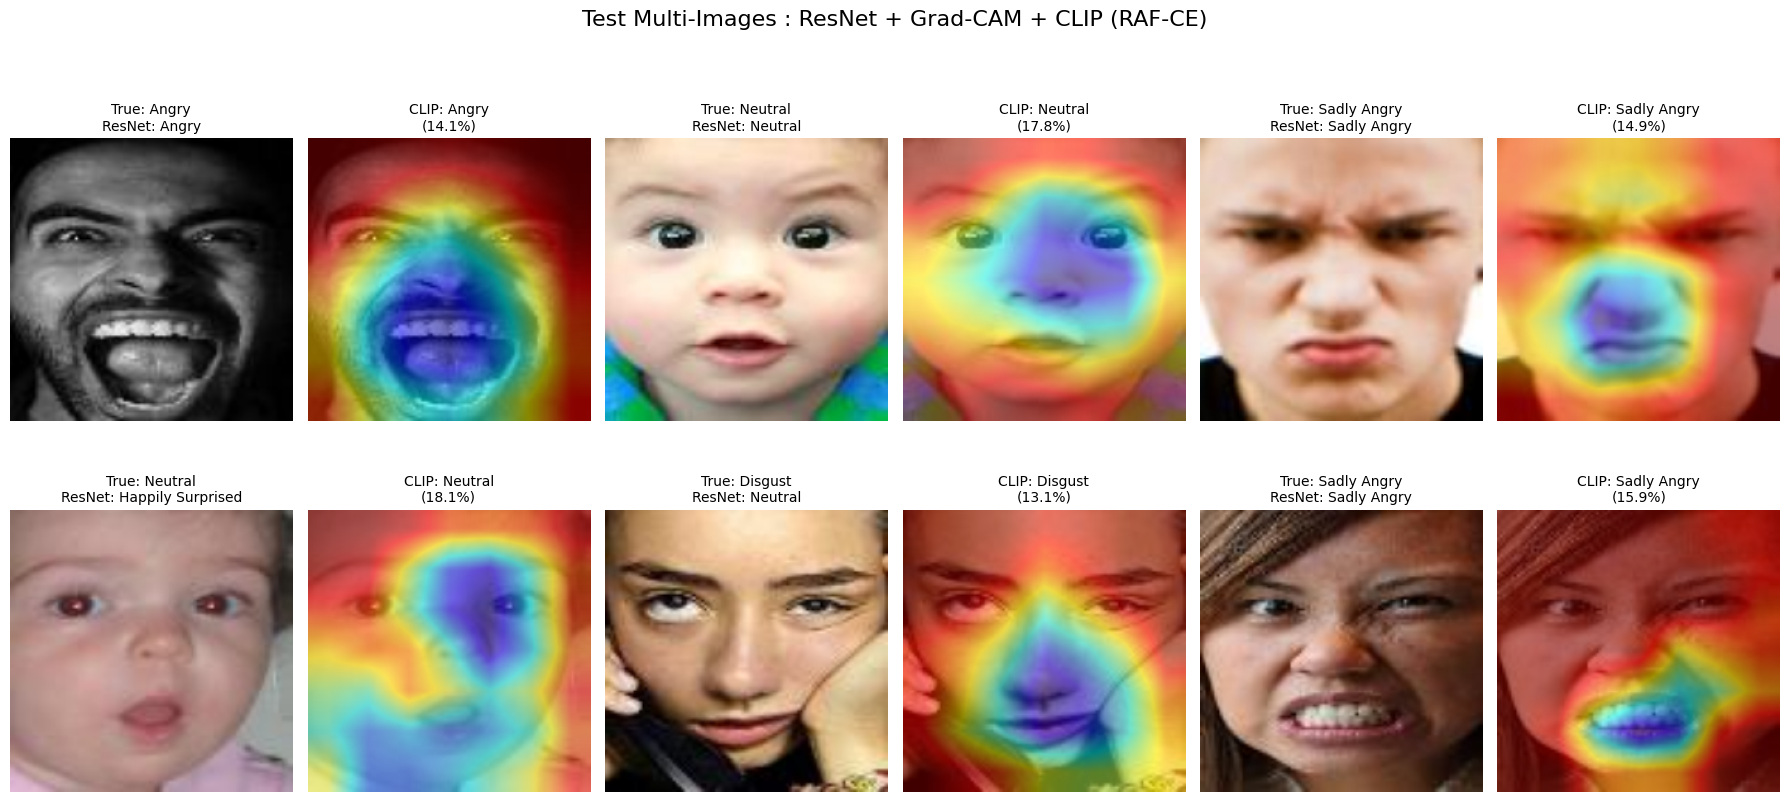

In [39]:
# ====================== TEST SUR PLUSIEURS IMAGES (VERSION CORRIGÉE) ======================
import random

print("🚀 Test sur 6 images aléatoires du Validation Set\n")

# Sélectionner 6 images aléatoires du val_dataset
indices = random.sample(range(len(val_dataset)), 6)

plt.figure(figsize=(18, 12))

for plot_idx, sample_idx in enumerate(indices):
    # Récupérer l'image et le label
    img_tensor, true_label = val_dataset[sample_idx]   # img_tensor est déjà un tensor normalisé

    # Convertir correctement en PIL (correction principale)
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()        # (224, 224, 3)
    img_np = (img_np * 0.5 + 0.5) * 255                       # denormalize
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)         # ← IMPORTANT : uint8
    img_pil = Image.fromarray(img_np).convert("RGB")

    # === Prédiction ResNet ===
    input_tensor = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_cnn = torch.argmax(probs, dim=1).item()

    # === Grad-CAM ===
    cam = gradcam.generate(input_tensor, pred_cnn)

    # === Prédiction CLIP ===
    pred_clip_idx, conf_clip = predict_clip(img_pil)

    # === Explication ===
    explanation = generate_explanation(pred_cnn, cam)

    # === Affichage ===
    img_display = np.array(img_pil.resize((224, 224)))

    # Superimposed Grad-CAM
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    superimposed = heatmap + np.float32(img_display) / 255.0
    superimposed = np.clip(superimposed / np.max(superimposed), 0, 1)

    # Plot
    plt.subplot(3, 6, plot_idx*2 + 1)
    plt.imshow(img_display)
    plt.title(f"True: {class_names[true_label]}\nResNet: {class_names[pred_cnn]}", fontsize=10)
    plt.axis("off")

    plt.subplot(3, 6, plot_idx*2 + 2)
    plt.imshow(superimposed)
    plt.title(f"CLIP: {class_names[pred_clip_idx]}\n({conf_clip*100:.1f}%)", fontsize=10)
    plt.axis("off")

    print(f"Image {plot_idx+1}: True = {class_names[true_label]} | "
          f"ResNet = {class_names[pred_cnn]} | CLIP = {class_names[pred_clip_idx]}")
    print(f"   → {explanation}\n")

plt.suptitle("Test Multi-Images : ResNet + Grad-CAM + CLIP (RAF-CE)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# ====================== TABLEAU COMPARAISON RESNET vs CLIP ======================
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

print("📊 Calcul des métriques sur tout le Validation Set...\n")

y_true = []
y_pred_resnet = []
y_pred_clip = []

model.eval()
model_clip.eval()

with torch.no_grad():
    for images, labels in val_loader:
        # ResNet
        images = images.to(device)
        outputs = model(images)
        preds_resnet = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred_resnet.extend(preds_resnet)

        # CLIP (une par une car il prend PIL)
        for i in range(images.size(0)):
            img_tensor = images[i]
            img_np = (img_tensor.permute(1,2,0).cpu().numpy() * 0.5 + 0.5) * 255
            img_pil = Image.fromarray(img_np.astype(np.uint8))
            pred_clip, _ = predict_clip(img_pil)
            y_pred_clip.append(pred_clip)

        y_true.extend(labels.cpu().numpy())

# Métriques
acc_resnet = accuracy_score(y_true, y_pred_resnet)
acc_clip = accuracy_score(y_true, y_pred_clip)
f1_resnet = f1_score(y_true, y_pred_resnet, average='macro')
f1_clip = f1_score(y_true, y_pred_clip, average='macro')

print(f"ResNet  → Accuracy: {acc_resnet:.4f} | Macro F1: {f1_resnet:.4f}")
print(f"CLIP    → Accuracy: {acc_clip:.4f} | Macro F1: {f1_clip:.4f}")

# Tableau
comparison = pd.DataFrame({
    "Modèle": ["ResNet18 (Fine-tuned)", "CLIP (ViT-B/32)"],
    "Accuracy": [acc_resnet, acc_clip],
    "Macro F1-Score": [f1_resnet, f1_clip]
})
display(comparison.round(4))

📊 Calcul des métriques sur tout le Validation Set...

ResNet  → Accuracy: 0.4901 | Macro F1: 0.3846
CLIP    → Accuracy: 0.5148 | Macro F1: 0.3870


,Modèle,Accuracy,Macro F1-Score
0,ResNet18 (Fine-tuned),0.4901,0.3846
1,CLIP (ViT-B/32),0.5148,0.3870


In [77]:
%%writefile app.py

import os
os.environ["STREAMLIT_SERVER_ENABLE_CORS"] = "false"
os.environ["STREAMLIT_SERVER_ENABLE_XSRF_PROTECTION"] = "false"

import streamlit as st
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import cv2
import numpy as np

from PIL import Image

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="FER-CE Emotion Recognition",
    page_icon="🎭",
    layout="wide"
)

st.title("🎭 FER-CE : Compound Emotion Recognition")
st.markdown("### ResNet18 + Grad-CAM")
st.write("Upload a face image to detect emotions.")

# =========================================================
# DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# CLASS NAMES
# =========================================================

class_names = [
    "Neutral",
    "Happy",
    "Sad",
    "Surprise",
    "Fear",
    "Disgust",
    "Angry",
    "Contempt",
    "Happily Surprised",
    "Sadly Angry",
    "Sadly Surprised",
    "Fearfully Surprised",
    "Angrily Surprised",
    "Disgustedly Surprised"
]

# =========================================================
# IMAGE TRANSFORM
# =========================================================

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================================================
# LOAD MODEL
# =========================================================

def load_model():

    model = models.resnet18(weights=None)

    num_ftrs = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 14)
    )

    model_path = "/content/drive/MyDrive/best_model.pth"

    if not os.path.exists(model_path):
        st.error(f"❌ Model not found:\n{model_path}")
        st.stop()

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model = model.to(device)
    model.eval()

    return model

# =========================================================
# LOAD RESNET
# =========================================================

with st.spinner("⏳ Loading ResNet18 model..."):
    model = load_model()

st.success("✅ Model loaded successfully")

# =========================================================
# GRAD-CAM
# =========================================================

class GradCAM:

    def __init__(self, model):

        self.model = model

        self.gradients = None
        self.activations = None

        self.target_layer = model.layer4[-1]

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, class_idx):

        self.model.zero_grad()

        output = self.model(input_image)

        loss = output[0, class_idx]

        loss.backward()

        gradients = self.gradients[0].cpu().numpy()
        activations = self.activations[0].cpu().numpy()

        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)

        cam = cv2.resize(cam, (224, 224))

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        cam = cv2.GaussianBlur(cam, (5, 5), 0)

        return cam

gradcam = GradCAM(model)

# =========================================================
# ATTENTION ANALYSIS
# =========================================================

def analyze_attention(cam):

    h, w = cam.shape

    top = np.mean(cam[:int(h*0.35)])
    middle = np.mean(cam[int(h*0.35):int(h*0.65)])
    bottom = np.mean(cam[int(h*0.65):])

    if top > bottom and top > middle:
        return "Eyes and eyebrows"

    elif bottom > top and bottom > middle:
        return "Mouth and lower face"

    else:
        return "Central face"

# =========================================================
# EXPLANATION
# =========================================================

def generate_explanation(pred_class, cam):

    emotion = class_names[pred_class]

    focus = analyze_attention(cam)

    return f"The AI predicts '{emotion}' and mainly focuses on {focus}."

# =========================================================
# FILE UPLOADER
# =========================================================

uploaded_file = st.file_uploader(
    "📤 Upload a face image",
    type=["jpg", "jpeg", "png"]
)

# =========================================================
# PREDICTION
# =========================================================

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Image",
        use_container_width=True
    )

    # -----------------------------------------------------
    # PREPROCESS
    # -----------------------------------------------------

    img_tensor = val_transform(image).unsqueeze(0).to(device)

    # -----------------------------------------------------
    # PREDICTION
    # -----------------------------------------------------

    with torch.no_grad():

        output = model(img_tensor)

        probs = torch.softmax(output, dim=1)

        pred = torch.argmax(probs, dim=1).item()

        confidence = probs[0][pred].item() * 100

    # -----------------------------------------------------
    # GRAD-CAM
    # -----------------------------------------------------

    cam = gradcam.generate(img_tensor, pred)

    # -----------------------------------------------------
    # EXPLANATION
    # -----------------------------------------------------

    explanation = generate_explanation(pred, cam)

    # -----------------------------------------------------
    # HEATMAP
    # -----------------------------------------------------

    img_np = np.array(image.resize((224, 224)))

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = np.float32(heatmap) / 255.0

    superimposed = heatmap + np.float32(img_np) / 255.0

    superimposed = superimposed / np.max(superimposed)

    # =====================================================
    # RESULTS
    # =====================================================

    st.markdown("---")

    st.success(
        f"""
        🧠 Prediction: {class_names[pred]}

        📊 Confidence: {confidence:.2f}%
        """
    )

    # =====================================================
    # GRAD-CAM DISPLAY
    # =====================================================

    st.markdown("## 🔥 Grad-CAM Attention Map")

    st.image(
        superimposed,
        caption="AI Attention Visualization",
        use_container_width=True
    )

    # =====================================================
    # EXPLANATION
    # =====================================================

    st.markdown("## 📖 AI Explanation")

    st.info(explanation)

    # =====================================================
    # PROBABILITIES
    # =====================================================

    st.markdown("## 📊 Emotion Probabilities")

    probs_np = probs[0].detach().cpu().numpy()

    chart_data = {}

    for i in range(len(class_names)):
        chart_data[class_names[i]] = float(probs_np[i])

    st.bar_chart(chart_data)

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("ℹ️ About")

st.sidebar.info(
    """
    FER-CE Compound Emotion Recognition

    ✅ ResNet18 Fine-Tuning
    ✅ Grad-CAM Explainability
    ✅ Compound Emotion Detection
    ✅ PyTorch + Streamlit

    Developed for AI Research & PFE
    """
)

st.sidebar.success("✅ Application Ready")

Overwriting app.py


In [78]:
!pip install streamlit pyngrok -q

In [79]:
!pkill -f streamlit

In [80]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [81]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://partake-backside-trickily.ngrok-free.dev" -> "http://localhost:8501"


In [61]:
!pip install streamlit pyngrok open_clip_torch peft bitsandbytes torchao -q

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
!pkill -f streamlit

In [64]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [65]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🔥 STREAMLIT LINK:")
print(public_url)

🔥 STREAMLIT LINK:
NgrokTunnel: "https://partake-backside-trickily.ngrok-free.dev" -> "http://localhost:8501"


In [66]:
!cat /content/logs.txt



2026-05-07 14:39:30.758 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.254.83:8501



In [67]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("🔥 PUBLIC URL:")
print(public_url)

🔥 PUBLIC URL:
NgrokTunnel: "https://partake-backside-trickily.ngrok-free.dev" -> "http://localhost:8501"


In [68]:
!tail -50 /content/logs.txt



2026-05-07 14:39:30.758 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.143.254.83:8501



In [69]:
from pyngrok import ngrok

# Fermer anciens tunnels
ngrok.kill()

# Créer tunnel public
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://partake-backside-trickily.ngrok-free.dev" -> "http://localhost:8501"


In [71]:
!npm install -g localtunnel
print("✅ localtunnel installé avec npm")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧✅ localtunnel installé avec npm


In [72]:

!curl -s https://ipv4.icanhazip.com

34.143.254.83


In [73]:
# Arrêter les anciens processus
!pkill -f streamlit
!pkill -f localtunnel

# Lancer Streamlit en arrière-plan
!streamlit run app.py &>/content/streamlit_logs.txt &
!sleep 8
print("✅ Streamlit lancé en arrière-plan")

# Lancer le tunnel
!npx localtunnel --port 8501 --subdomain fer-ce-hiba-final

✅ Streamlit lancé en arrière-plan
⠙⠹⠸⠼⠴⠦⠧your url is: https://fer-ce-hiba-final.loca.lt
^C


In [74]:
import subprocess, time, requests

# Kill old processes
!pkill -f streamlit
!pkill -f localtunnel
time.sleep(2)

# Get public IP (needed for loca.lt bypass)
ip = subprocess.getoutput("curl -s https://ipv4.icanhazip.com").strip()
print(f"📡 IP: {ip}")

# Launch Streamlit on port 8501 explicitly
!streamlit run app.py --server.port 8501 --server.headless true &>/content/streamlit_logs.txt &
time.sleep(8)
print("✅ Streamlit lancé")

# Launch LocalTunnel
!npx localtunnel --port 8501 --subdomain fer-ce-hiba-final &>/content/lt_logs.txt &
time.sleep(5)
print("✅ Tunnel lancé")
print(f"\n🔗 URL: https://fer-ce-hiba-final.loca.lt")
print(f"🔑 Mot de passe tunnel (si demandé): {ip}")

📡 IP: 34.143.254.83
✅ Streamlit lancé
✅ Tunnel lancé

🔗 URL: https://fer-ce-hiba-final.loca.lt
🔑 Mot de passe tunnel (si demandé): 34.143.254.83
